In [4]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
dataset = pd.read_csv('survey lung cancer.csv')

In [6]:
dataset

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,M,69,1,2,2,1,1,2,1,2,2,2,2,2,2,YES
1,M,74,2,1,1,1,2,2,2,1,1,1,2,2,2,YES
2,F,59,1,1,1,2,1,2,1,2,1,2,2,1,2,NO
3,M,63,2,2,2,1,1,1,1,1,2,1,1,2,2,NO
4,F,63,1,2,1,1,1,1,1,2,1,2,2,1,1,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
304,F,56,1,1,1,2,2,2,1,1,2,2,2,2,1,YES
305,M,70,2,1,1,1,1,2,2,2,2,2,2,1,2,YES
306,M,58,2,1,1,1,1,1,2,2,2,2,1,1,2,YES
307,M,67,2,1,2,1,1,2,2,1,2,2,2,1,2,YES


In [7]:
import scipy
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression()
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

In [9]:
from sklearn.metrics import accuracy_score, classification_report 
from sklearn.metrics import confusion_matrix

In [10]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 309 entries, 0 to 308
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   GENDER                 309 non-null    object
 1   AGE                    309 non-null    int64 
 2   SMOKING                309 non-null    int64 
 3   YELLOW_FINGERS         309 non-null    int64 
 4   ANXIETY                309 non-null    int64 
 5   PEER_PRESSURE          309 non-null    int64 
 6   CHRONIC DISEASE        309 non-null    int64 
 7   FATIGUE                309 non-null    int64 
 8   ALLERGY                309 non-null    int64 
 9   WHEEZING               309 non-null    int64 
 10  ALCOHOL CONSUMING      309 non-null    int64 
 11  COUGHING               309 non-null    int64 
 12  SHORTNESS OF BREATH    309 non-null    int64 
 13  SWALLOWING DIFFICULTY  309 non-null    int64 
 14  CHEST PAIN             309 non-null    int64 
 15  LUNG_CANCER            

In [11]:
#Generates descriptive statistics (mean, std, min, max, count, and percentiles) for numerical columns and 
#Rounds all numerical values in the table to two decimal
round(dataset.describe().T,2)

,count,mean,std,min,25%,50%,75%,max
AGE,309.0,62.67,8.21,21.0,57.0,62.0,69.0,87.0
SMOKING,309.0,1.56,0.50,1.0,1.0,2.0,2.0,2.0
YELLOW_FINGERS,309.0,1.57,0.50,1.0,1.0,2.0,2.0,2.0
ANXIETY,309.0,1.50,0.50,1.0,1.0,1.0,2.0,2.0
PEER_PRESSURE,309.0,1.50,0.50,1.0,1.0,2.0,2.0,2.0
CHRONIC DISEASE,309.0,1.50,0.50,1.0,1.0,2.0,2.0,2.0
FATIGUE,309.0,1.67,0.47,1.0,1.0,2.0,2.0,2.0
ALLERGY,309.0,1.56,0.50,1.0,1.0,2.0,2.0,2.0
WHEEZING,309.0,1.56,0.50,1.0,1.0,2.0,2.0,2.0
ALCOHOL CONSUMING,309.0,1.56,0.50,1.0,1.0,2.0,2.0,2.0


In [12]:
def d_null(dataset):
    d_null=dataset.isna().sum()
    if d_null[d_null>0].any() :
        print(d_null[d_null>0])
    else:
        print('NO Missing')
d_null(dataset)

NO Missing


In [13]:
dataset.duplicated().sum()

np.int64(33)

In [14]:
dataset.columns.tolist()

['GENDER',
 'AGE',
 'SMOKING',
 'YELLOW_FINGERS',
 'ANXIETY',
 'PEER_PRESSURE',
 'CHRONIC DISEASE',
 'FATIGUE ',
 'ALLERGY ',
 'WHEEZING',
 'ALCOHOL CONSUMING',
 'COUGHING',
 'SHORTNESS OF BREATH',
 'SWALLOWING DIFFICULTY',
 'CHEST PAIN',
 'LUNG_CANCER']

In [15]:
dataset.columns=dataset.columns.str.lower()

In [16]:
dataset.drop_duplicates(inplace=True)

In [17]:
dataset.shape

(276, 16)

In [18]:
dataset['lung_cancer'].replace({'YES':2,'NO':1},inplace=True)
dataset[['lung_cancer']]

,lung_cancer
0,2
1,2
2,1
3,1
4,1
...,...
279,2
280,1
281,1
282,1


In [19]:
dataset['gender'].replace({'M':1,'F':0},inplace=True)
dataset[['gender']]

,gender
0,1
1,1
2,0
3,1
4,0
...,...
279,0
280,0
281,1
282,1


In [20]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 276 entries, 0 to 283
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   gender                 276 non-null    int64
 1   age                    276 non-null    int64
 2   smoking                276 non-null    int64
 3   yellow_fingers         276 non-null    int64
 4   anxiety                276 non-null    int64
 5   peer_pressure          276 non-null    int64
 6   chronic disease        276 non-null    int64
 7   fatigue                276 non-null    int64
 8   allergy                276 non-null    int64
 9   wheezing               276 non-null    int64
 10  alcohol consuming      276 non-null    int64
 11  coughing               276 non-null    int64
 12  shortness of breath    276 non-null    int64
 13  swallowing difficulty  276 non-null    int64
 14  chest pain             276 non-null    int64
 15  lung_cancer            276 non-null    int64


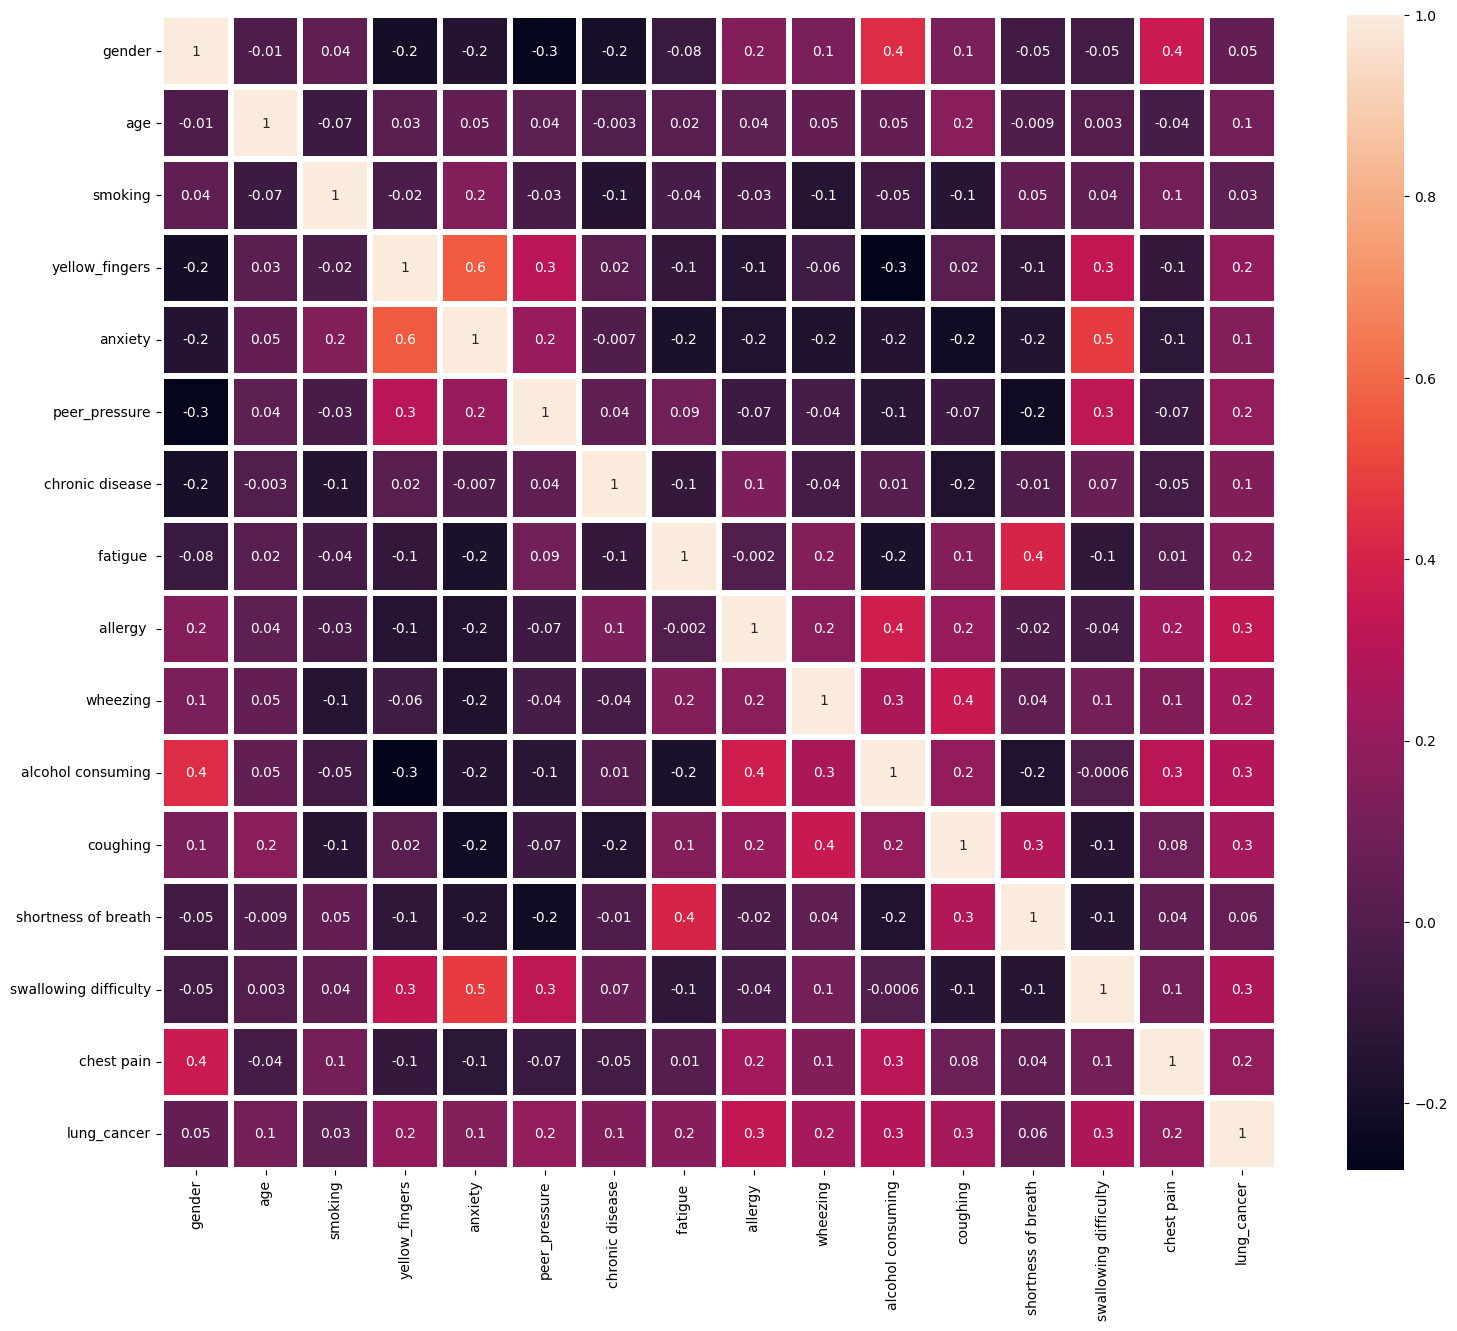

In [21]:
corr_matrix=dataset.corr()
plt.figure(figsize=(18,15))
sns.heatmap(corr_matrix,annot=True,linewidths=4,fmt='.1g',)
plt.show()

In [22]:
dataset['age'].value_counts()

age
64    18
60    16
62    16
56    16
59    15
63    15
61    14
70    14
67    11
55    10
72    10
69    10
68     9
77     9
57     9
71     9
58     8
54     7
74     6
75     5
51     5
65     5
52     4
66     4
73     4
53     4
49     3
76     3
47     3
48     2
44     2
81     2
78     2
21     1
79     1
38     1
39     1
87     1
46     1
Name: count, dtype: int64

In [23]:
len(dataset[dataset.age<49])

11

Text(0.5, 1.0, 'Age Distribution')

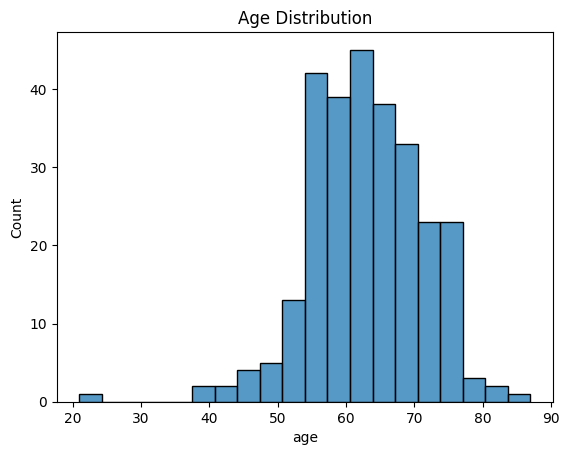

In [24]:
sns.histplot(x='age',data=dataset)
plt.title('Age Distribution')

In [25]:
#Spearman rank-order correlation coefficient and the associated p-value between a person's age and the presence/severity of lung cancer
scipy.stats.spearmanr(dataset['age'],dataset['lung_cancer'])

SignificanceResult(statistic=np.float64(0.09656644092639528), pvalue=np.float64(0.10943355450879182))

In [26]:
age_dataset=dataset[['age','chest pain','coughing', 'swallowing difficulty']]
age_dataset.corr()

,age,chest pain,coughing,swallowing difficulty
age,1.000000,-0.035806,0.168654,0.003199
chest pain,-0.035806,1.000000,0.077988,0.102674
coughing,0.168654,0.077988,1.000000,-0.136885
swallowing difficulty,0.003199,0.102674,-0.136885,1.000000


In [27]:
age_gr = dataset.groupby(['age', 'chest pain', 'coughing', 'swallowing difficulty'], as_index=False).size()
age_gr.rename(columns={'size': 'count'}, inplace=True)
print(age_gr)

     age  chest pain  coughing  swallowing difficulty  count
0     21           1         1                      1      1
1     38           2         2                      1      1
2     39           2         1                      1      1
3     44           1         1                      2      1
4     44           2         1                      2      1
..   ...         ...       ...                    ...    ...
158   78           2         1                      2      1
159   79           2         2                      2      1
160   81           1         2                      1      1
161   81           2         2                      2      1
162   87           1         1                      1      1

[163 rows x 5 columns]


In [28]:
dataset.gender.value_counts()

gender
1    142
0    134
Name: count, dtype: int64

In [29]:
dataset.columns

Index(['gender', 'age', 'smoking', 'yellow_fingers', 'anxiety',
       'peer_pressure', 'chronic disease', 'fatigue ', 'allergy ', 'wheezing',
       'alcohol consuming', 'coughing', 'shortness of breath',
       'swallowing difficulty', 'chest pain', 'lung_cancer'],
      dtype='object')

<Axes: xlabel='gender'>

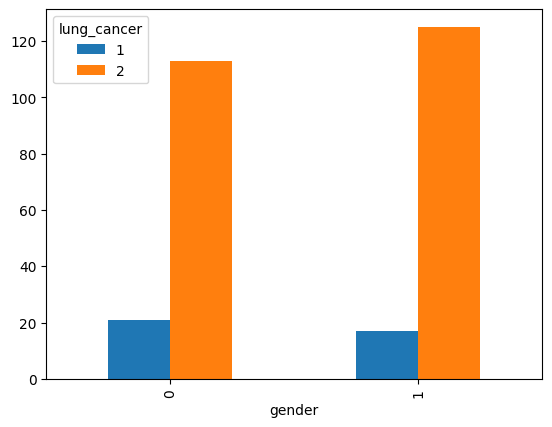

In [30]:
sex=pd.crosstab(dataset.gender,dataset['lung_cancer'])
sex.plot.bar()

In [31]:
#result will be a new DataFrame with a hierarchical index (MultiIndex) based on the three grouping columns
dataset.groupby(['gender', 'peer_pressure','lung_cancer']).agg({'age': ['min', 'max', 'mean']})

age               
                                 min max       mean
gender peer_pressure lung_cancer                   
0      1             1            21  87  60.833333
                     2            38  75  63.433333
       2             1            57  64  60.000000
                     2            44  81  63.457831
1      1             1            46  69  58.200000
                     2            48  79  63.230769
       2             1            59  69  64.142857
                     2            39  78  62.872340

In [32]:
dataset.groupby(['gender', 'chest pain','lung_cancer']).agg({'age': ['min', 'max', 'mean']})

age               
                              min max       mean
gender chest pain lung_cancer                   
0      1          1            21  87  61.000000
                  2            44  81  63.738462
       2          1            57  59  58.000000
                  2            38  81  63.062500
1      1          1            55  68  61.571429
                  2            52  77  63.967742
       2          1            46  69  60.000000
                  2            39  79  62.808511

In [33]:
#weak positive 
scipy.stats.spearmanr(dataset['gender'],dataset['lung_cancer'])

SignificanceResult(statistic=np.float64(0.0536655779607626), pvalue=np.float64(0.3744582204386846))

In [34]:
## Calculate sizes of unique combinations of gender, age, and lung_cancer
gr = dataset.groupby(['gender', 'age', 'lung_cancer']).size().reset_index(name='count')

In [35]:
#Filter for females (assuming gender 0 is female)
female = gr[gr['gender'] == 0]
fem_gr = pd.DataFrame(female)
fem_gr

,gender,age,lung_cancer,count
0,0,21,1,1
1,0,38,2,1
2,0,44,2,1
3,0,47,2,1
4,0,48,2,1
5,0,49,2,2
6,0,51,2,3
7,0,53,2,2
8,0,54,2,5
9,0,55,1,1


In [36]:
#Filter for females (assuming gender 1 is male)
male=gr[gr['gender']==1]
male_gr=pd.DataFrame(male)
male_gr

,gender,age,lung_cancer,count
49,1,39,2,1
50,1,44,2,1
51,1,46,1,1
52,1,47,1,1
53,1,47,2,1
54,1,48,2,1
55,1,49,2,1
56,1,51,2,2
57,1,52,2,4
58,1,53,2,2


In [37]:
dataset.smoking.value_counts()

smoking
2    150
1    126
Name: count, dtype: int64

In [38]:
sm=pd.crosstab(dataset.smoking,dataset['lung_cancer'])
sm

lung_cancer,1,2
smoking,,
1,19,107
2,19,131


<Axes: xlabel='smoking', ylabel='count'>

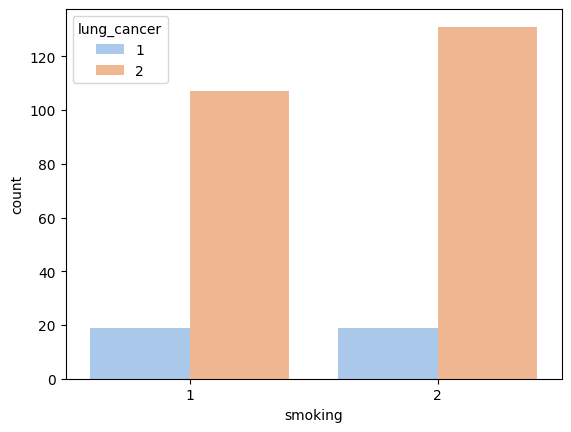

In [39]:
sns.countplot(x='smoking',hue='lung_cancer',data=dataset,palette='pastel')

In [40]:
scipy.stats.spearmanr(dataset['smoking'],dataset['lung_cancer'])

SignificanceResult(statistic=np.float64(0.03487816787960422), pvalue=np.float64(0.563949270194642))

<Axes: >

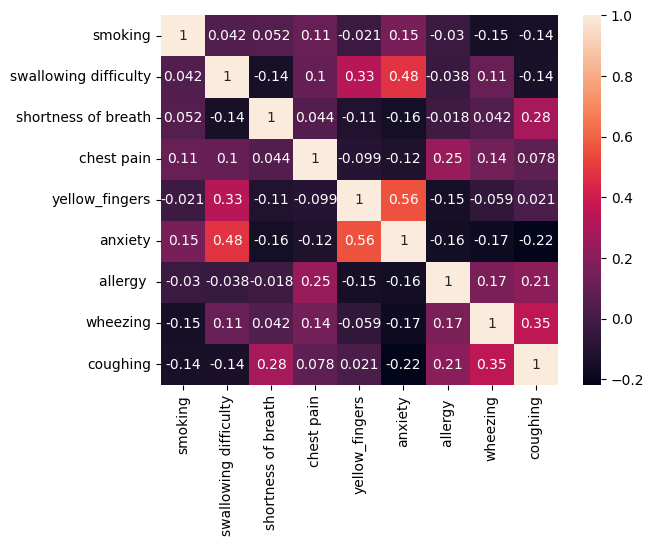

In [41]:
data_sm=dataset[['smoking','swallowing difficulty','shortness of breath','chest pain','yellow_fingers', 'anxiety','allergy ', 'wheezing','coughing']]
sm_corr=data_sm.corr()
sns.heatmap(sm_corr,annot=True)

<Axes: xlabel='smoking'>

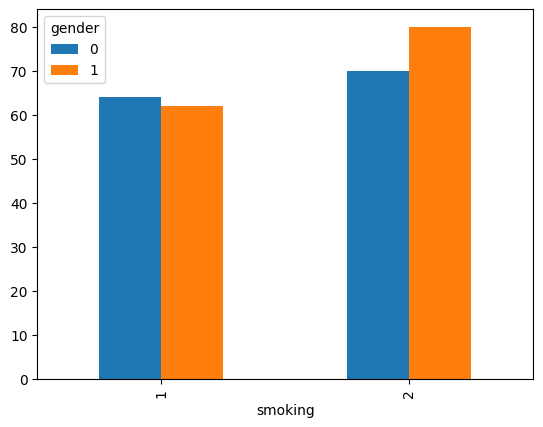

In [42]:
pd.crosstab(dataset.smoking,dataset.gender).plot.bar()

<Axes: xlabel='smoking'>

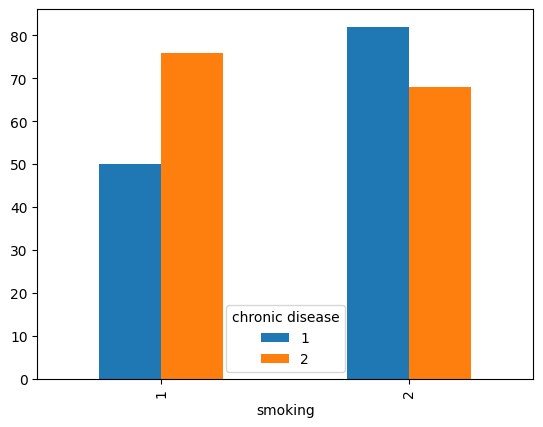

In [43]:
pd.crosstab(dataset.smoking,dataset['chronic disease']).plot.bar()

<Axes: xlabel='smoking'>

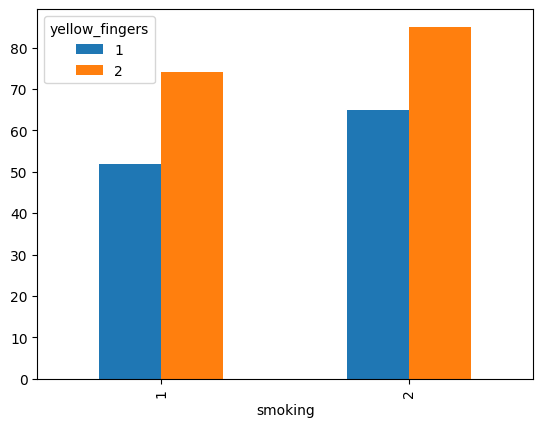

In [44]:
pd.crosstab(dataset.smoking,dataset['yellow_fingers']).plot.bar()

<Axes: xlabel='smoking'>

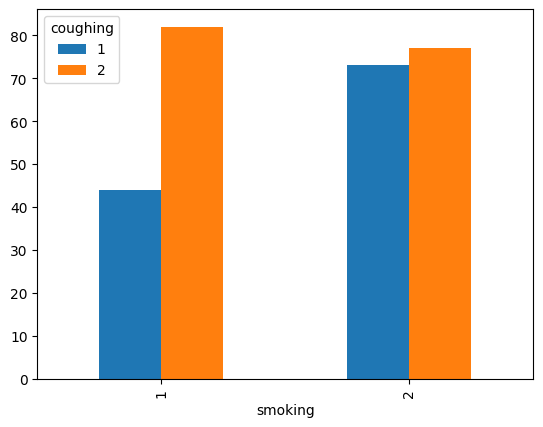

In [45]:
pd.crosstab(dataset.smoking,dataset['coughing']).plot.bar()

<Axes: xlabel='smoking'>

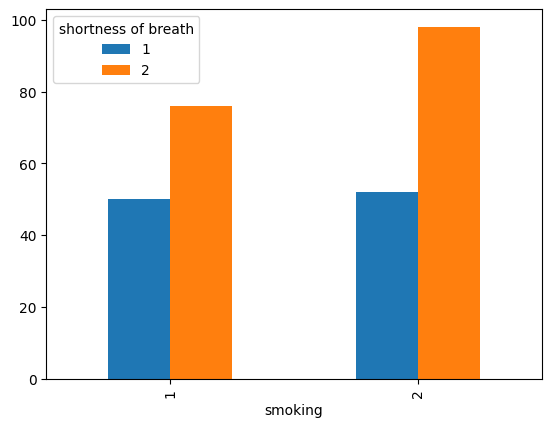

In [46]:
pd.crosstab(dataset.smoking,dataset['shortness of breath']).plot.bar()

In [47]:
dataset.lung_cancer.value_counts()

lung_cancer
2    238
1     38
Name: count, dtype: int64

In [48]:
scipy.stats.spearmanr(dataset['chest pain'],dataset['lung_cancer'])

SignificanceResult(statistic=np.float64(0.1948557222318186), pvalue=np.float64(0.0011389714581002597))

In [49]:
scipy.stats.spearmanr(dataset['alcohol consuming'],dataset['lung_cancer'])

SignificanceResult(statistic=np.float64(0.2944221403875563), pvalue=np.float64(6.36085868778738e-07))

In [50]:
scipy.stats.spearmanr(dataset['peer_pressure'],dataset['lung_cancer'])

SignificanceResult(statistic=np.float64(0.19508605044975108), pvalue=np.float64(0.0011233493083850593))

In [51]:
scipy.stats.spearmanr(dataset['anxiety'],dataset['lung_cancer'])

SignificanceResult(statistic=np.float64(0.14432182569353633), pvalue=np.float64(0.016424339633146007))

Number of unique values ("gender"): 2
        count
gender       
Yes       142
0         134


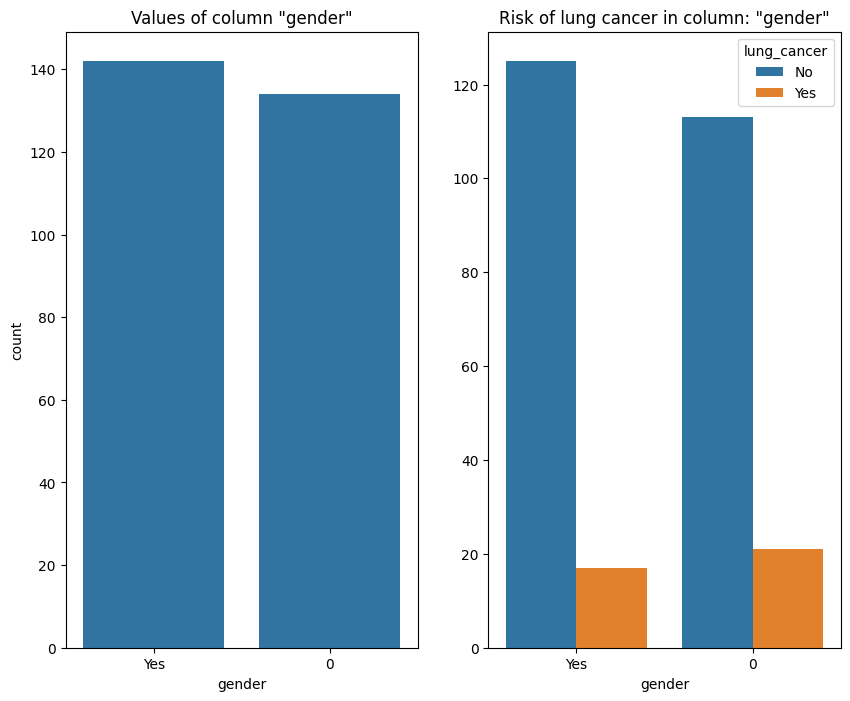

Number of unique values ("smoking"): 2
         count
smoking       
No         150
Yes        126


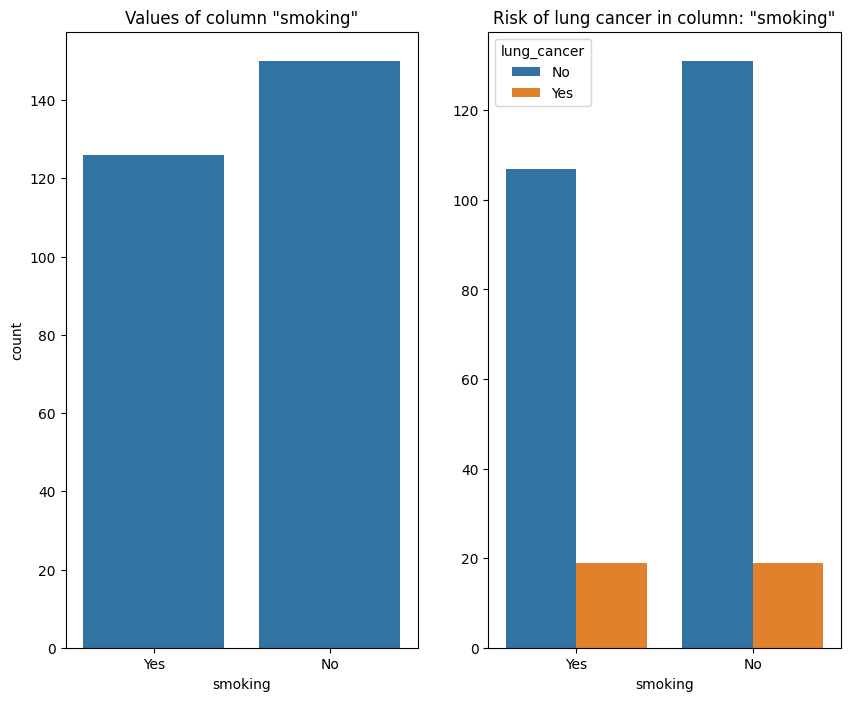

Number of unique values ("yellow_fingers"): 2
                count
yellow_fingers       
No                159
Yes               117


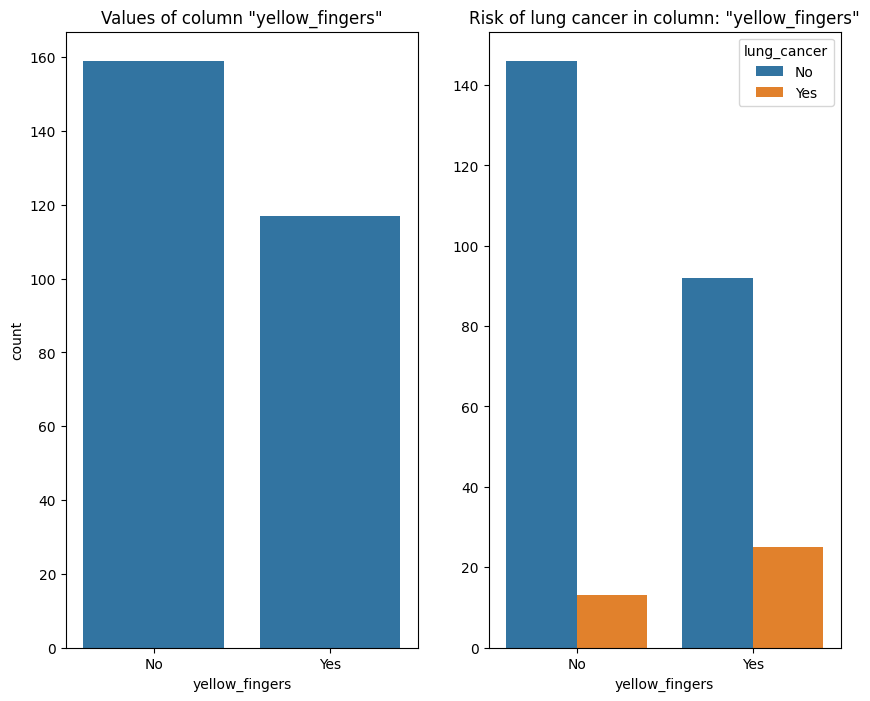

Number of unique values ("anxiety"): 2
         count
anxiety       
Yes        139
No         137


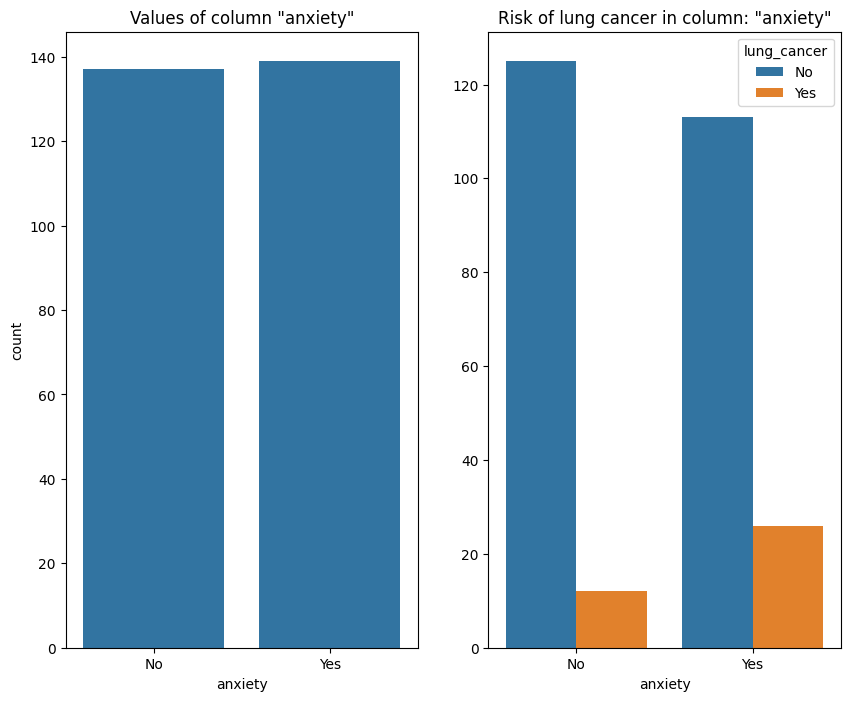

Number of unique values ("peer_pressure"): 2
               count
peer_pressure       
No               140
Yes              136


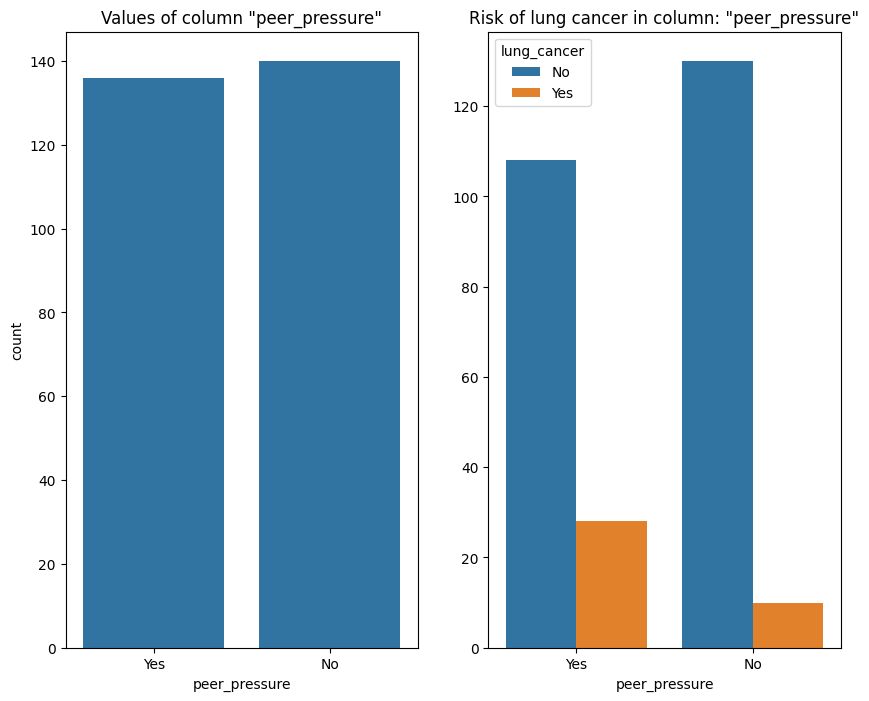

Number of unique values ("chronic disease"): 2
                 count
chronic disease       
No                 144
Yes                132


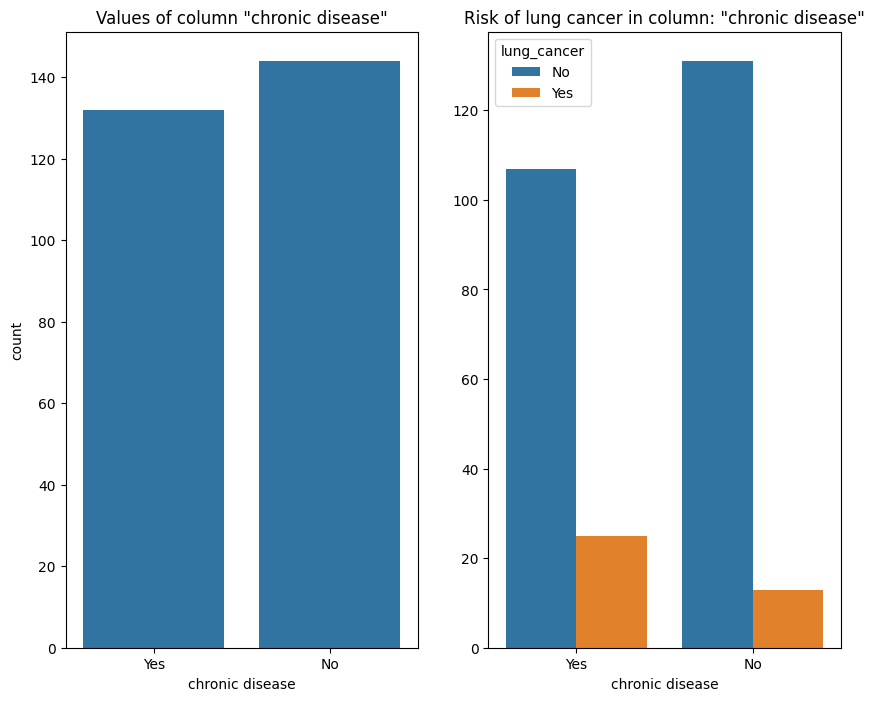

Number of unique values ("fatigue "): 2
          count
fatigue        
No          183
Yes          93


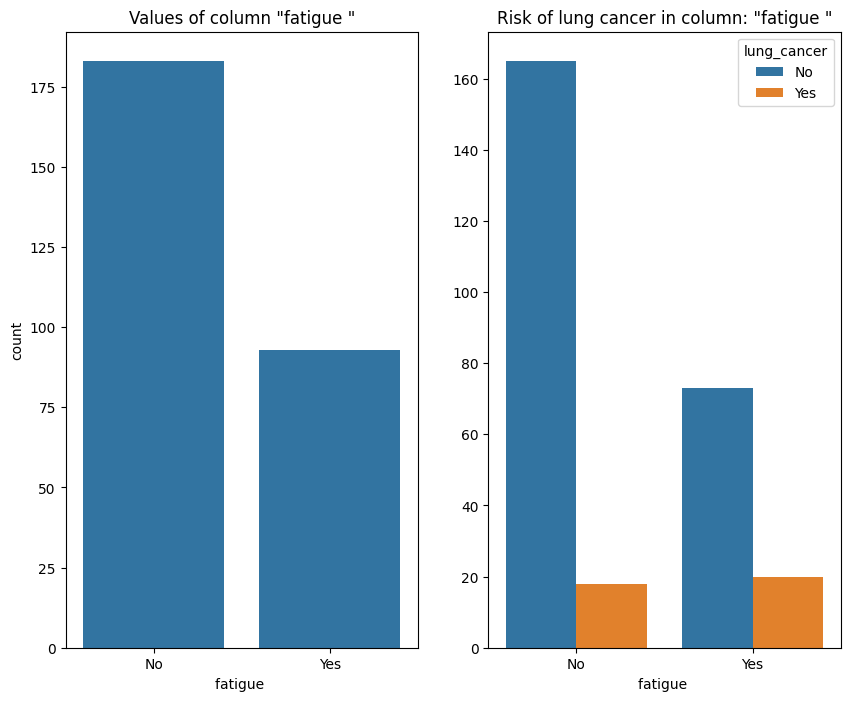

Number of unique values ("allergy "): 2
          count
allergy        
No          151
Yes         125


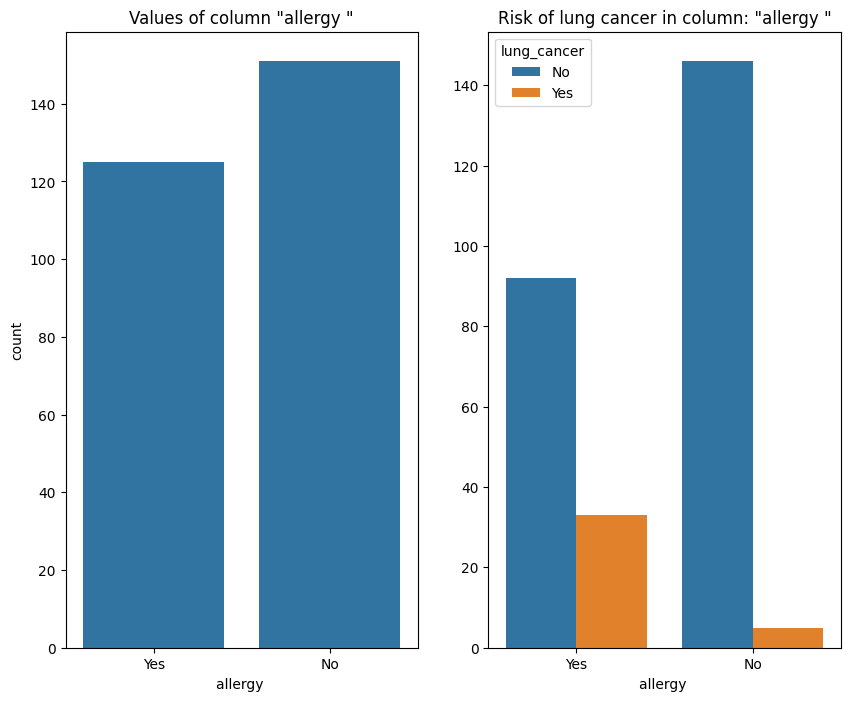

Number of unique values ("wheezing"): 2
          count
wheezing       
No          151
Yes         125


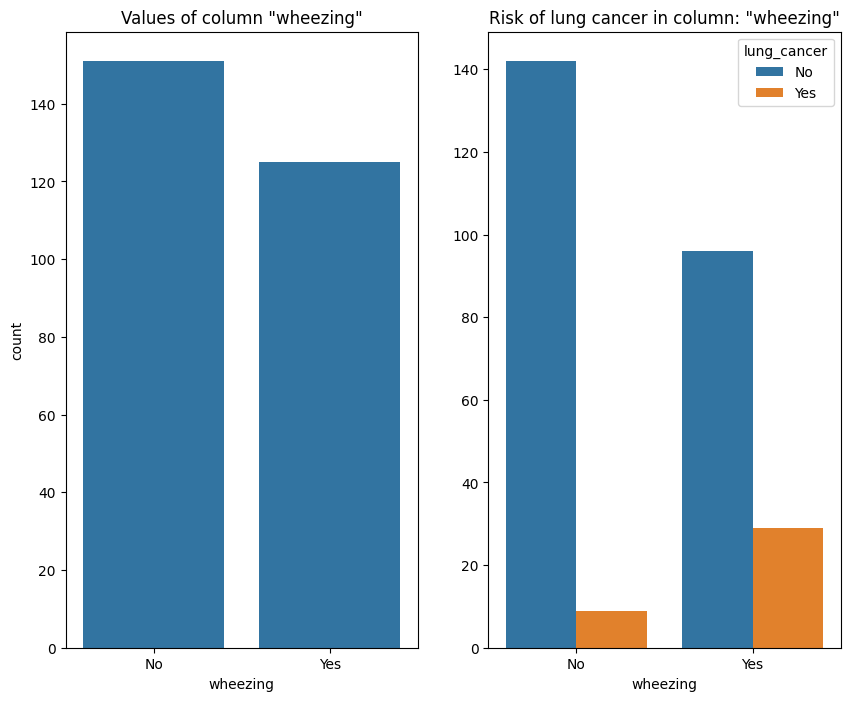

Number of unique values ("alcohol consuming"): 2
                   count
alcohol consuming       
No                   152
Yes                  124


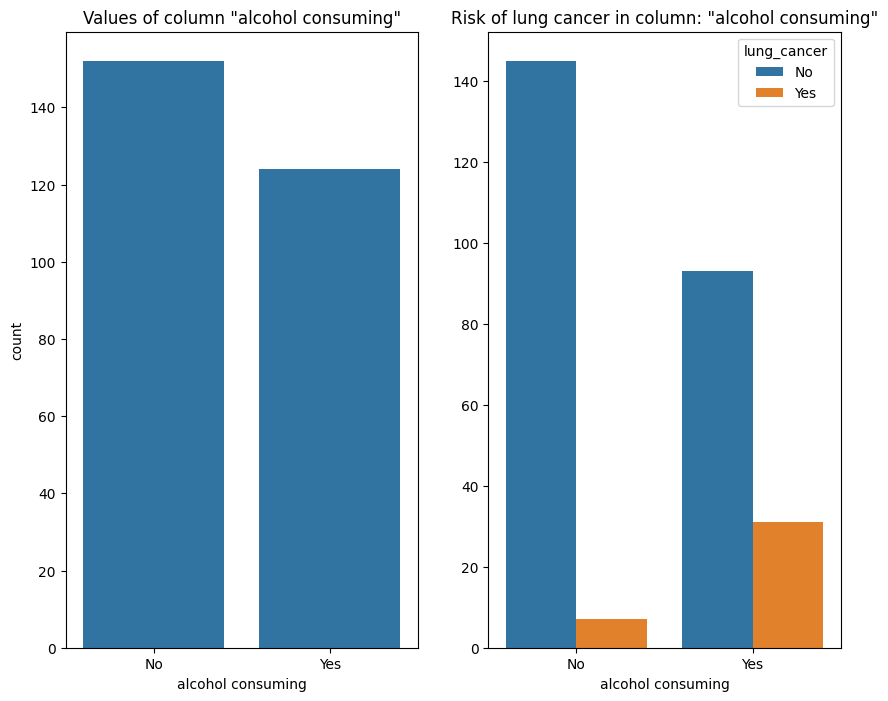

Number of unique values ("coughing"): 2
          count
coughing       
No          159
Yes         117


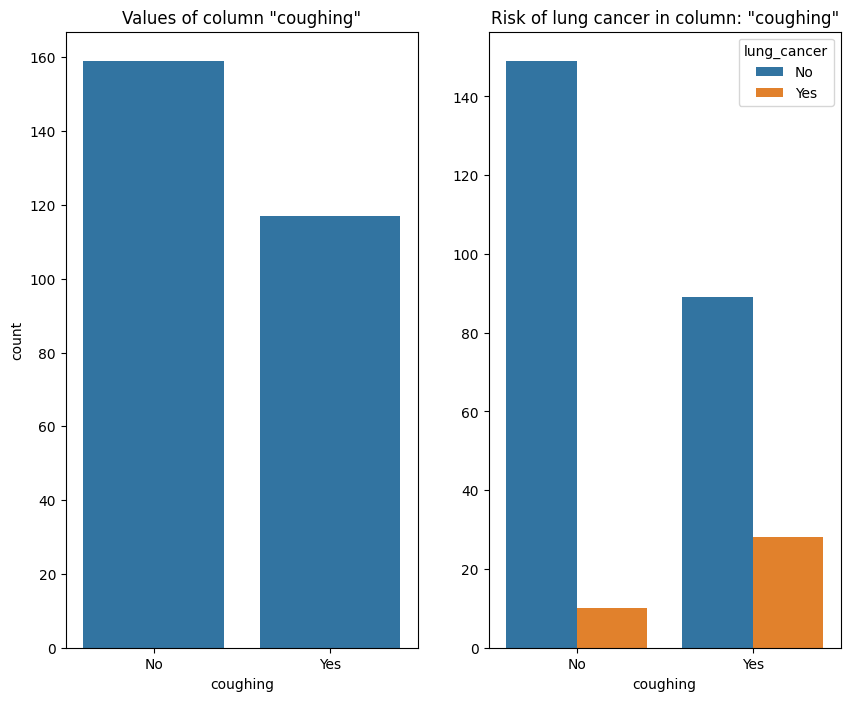

Number of unique values ("shortness of breath"): 2
                     count
shortness of breath       
No                     174
Yes                    102


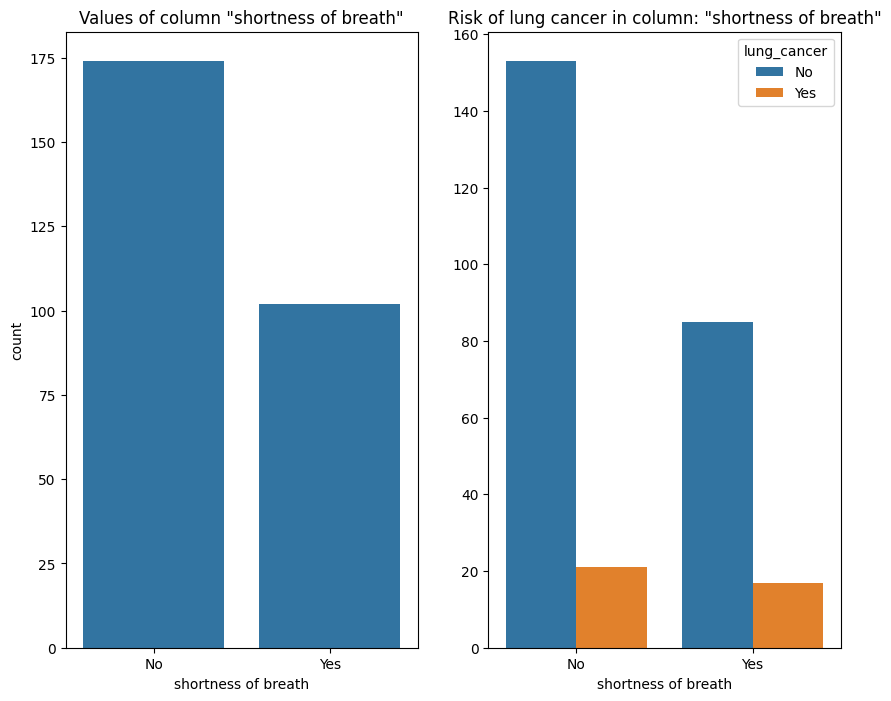

Number of unique values ("swallowing difficulty"): 2
                       count
swallowing difficulty       
Yes                      147
No                       129


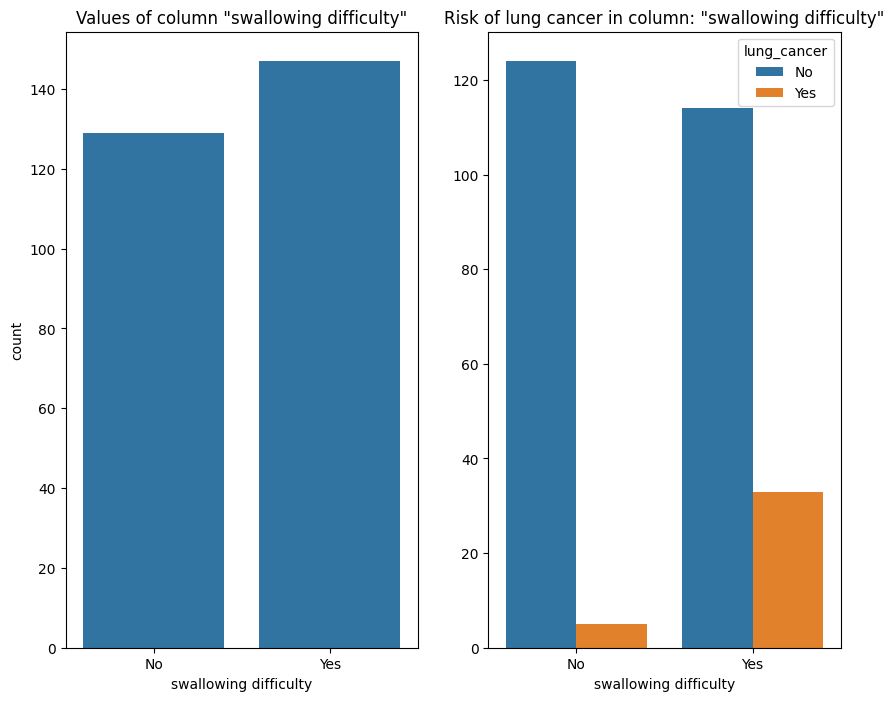

Number of unique values ("chest pain"): 2
            count
chest pain       
No            154
Yes           122


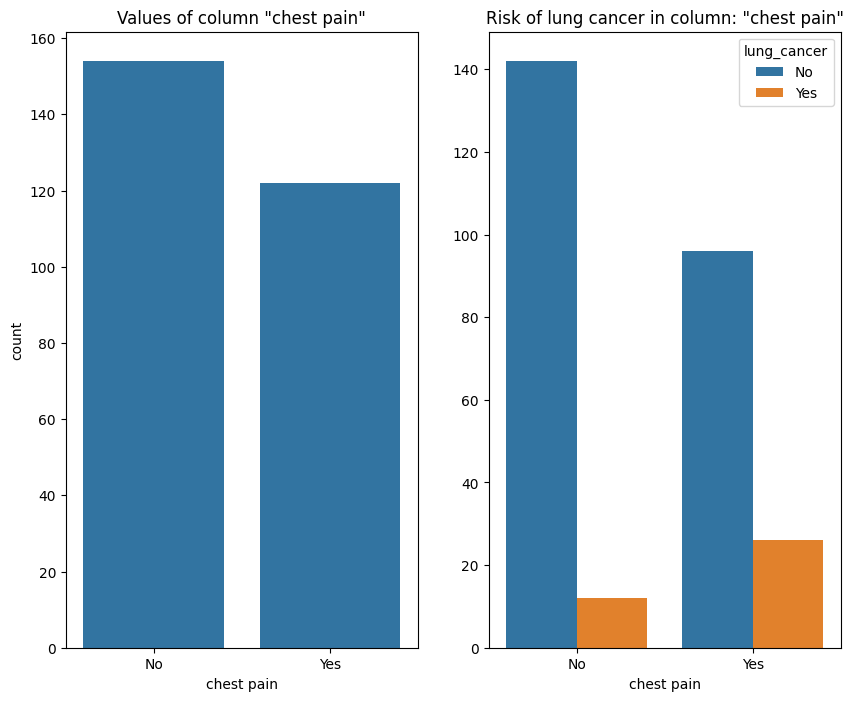

In [52]:
def plot_col(dataframe):
    dataframe = dataset.drop(['age'], axis=1)
    dataframe = dataframe.astype('str')
    dataframe = dataframe.replace({'1':'Yes', '2':'No'})

    for col in dataframe.columns:
        if col != 'lung_cancer':
            print(f'Number of unique values ("{col}"): {dataframe[col].nunique()}')
            print(pd.DataFrame(dataframe[col].value_counts()))
            fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 8))
            sns.countplot(data=dataframe, x=col, hue='lung_cancer', ax=ax[1]);
            ax[1].set_title(f'Risk of lung cancer in column: "{col}"')
            ax[1].set_ylabel('')
            sns.countplot(data=dataframe, x=col, ax=ax[0]);
            ax[0].set_title(f'Values of column "{col}"')
            plt.show()

plot_col(dataset)

In [53]:
pd.crosstab(dataset['lung_cancer'],dataset['swallowing difficulty'],margins=True)

swallowing difficulty,1,2,All
lung_cancer,,,
1,33,5,38
2,114,124,238
All,147,129,276


In [54]:
x=dataset.drop('lung_cancer',axis=1)
y=dataset['lung_cancer']

In [55]:
scale = StandardScaler()
xscale = scale.fit_transform(x)

In [56]:
x_train,x_test,y_train,y_test=train_test_split(xscale,y,test_size=0.2,random_state=42)

In [57]:
log_reg=LogisticRegression()
rf_clf=RandomForestClassifier()
svc=SVC()

In [58]:
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

In [59]:
def all(model):
    model.fit(x_train,y_train)
    y_pred=model.predict(x_test)
    accuracy_test=accuracy_score(y_pred,y_test)*100
    accuracy_train=model.score(x_train,y_train)*100
    print('accuracy after train model :',accuracy_train)
    print('accuracy after test  model :',accuracy_test)

In [60]:
all(log_reg)

accuracy after train model : 93.18181818181817
accuracy after test  model : 92.85714285714286


In [61]:
all(rf_clf)

accuracy after train model : 100.0
accuracy after test  model : 87.5


In [62]:
all(svc)

accuracy after train model : 94.54545454545455
accuracy after test  model : 83.92857142857143


In [63]:
len(dataset.columns)

16

In [64]:

def cm(model):
    y_pred = model.predict(x_test)
    
    # Calculate the raw confusion matrix
    cm_data = confusion_matrix(y_test, y_pred)
    
    plt.figure(figsize=(8, 6))
    
    # Create the heatmap
    # annot=True: shows the numbers in each cell
    # fmt='d': ensures numbers are displayed as integers (not scientific notation)
    # cmap='Greens': matches your original color choice
    sns.heatmap(cm_data, annot=True, fmt='d', cmap='Greens', 
                xticklabels=model.classes_, 
                yticklabels=model.classes_)
    
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

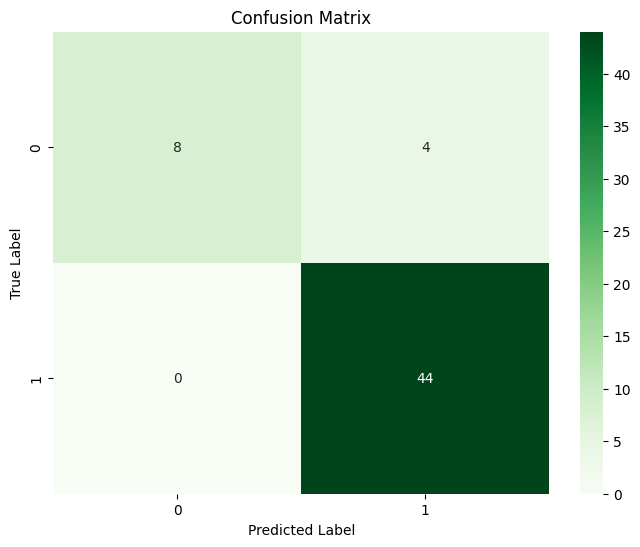

In [65]:
cm(log_reg)

In [125]:
def class_report(model):
    y_pred=model.predict(x_test)
    report = classification_report(y_test, y_pred, target_names=['Benign', 'Malignant'])
    print("Classification Report:\n", report)

In [126]:
from sklearn.feature_selection import SelectKBest, f_classif

In [127]:
dataset

,gender,age,smoking,yellow_fingers,anxiety,peer_pressure,chronic disease,fatigue,allergy,wheezing,alcohol consuming,coughing,shortness of breath,swallowing difficulty,chest pain,lung_cancer
0,1,69,1,2,2,1,1,2,1,2,2,2,2,2,2,2
1,1,74,2,1,1,1,2,2,2,1,1,1,2,2,2,2
2,0,59,1,1,1,2,1,2,1,2,1,2,2,1,2,1
3,1,63,2,2,2,1,1,1,1,1,2,1,1,2,2,1
4,0,63,1,2,1,1,1,1,1,2,1,2,2,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
279,0,59,1,2,2,2,1,1,2,2,1,2,1,2,1,2
280,0,59,2,1,1,1,2,2,2,1,1,1,2,1,1,1
281,1,55,2,1,1,1,1,2,2,1,1,1,2,1,2,1
282,1,46,1,2,2,1,1,1,1,1,1,1,1,2,2,1


In [128]:
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectKBest, f_classif
import pickle

In [129]:
# 1. Separate features and target
X = dataset.drop(columns=['lung_cancer'])
y = dataset['lung_cancer']

In [130]:
# 2. Select 5 best features
selector = SelectKBest(score_func=f_classif, k=5)
X_new = selector.fit_transform(X, y)

In [131]:
# 3. Get selected feature names
selected_features = X.columns[selector.get_support()]

print("Selected 5 Features:")
print(selected_features)

Selected 5 Features:
Index(['allergy ', 'wheezing', 'alcohol consuming', 'coughing',
       'swallowing difficulty'],
      dtype='object')


In [132]:
# 4. Create a new dataset containing only selected features
X_selected = X[selected_features]

In [133]:
# 5. Train Logistic Regression on the SELECTED features
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_selected, y)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [134]:
# 6. Check number of features
print("Number of features:", log_reg.n_features_in_)

Number of features: 5


In [135]:
import pickle

# Save the trained model itself
filename = "finalized_model_log_reg_selected_5_features.sav"

with open(filename, "wb") as f:
    pickle.dump(log_reg, f)

print("Model saved successfully!")

Model saved successfully!


In [136]:
with open(filename, "rb") as f:
    loaded_model = pickle.load(f)

print("Model loaded successfully!")
print("Number of features:", loaded_model.n_features_in_)

Model loaded successfully!
Number of features: 5
